# Readability Score Analysis

This notebook computes the Flesch readability scores for the original and plain corpora using the same logic as `run_simple.py` and visualises the distribution with a Seaborn violin plot.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from paper_easy_plain_german_datasets.utils import process_folder

In [7]:
from pathlib import Path

# Define the corpus directories (relative to the project root)
CRAWLED_ORIG = Path("data/crawled/orig")
CRAWLED_PLAIN = Path("data/crawled/plain")
CRAWLED_EASY = Path("data/crawled/easy")

# Disable caching for notebook runs to always compute fresh scores.
orig_scores = process_folder(CRAWLED_ORIG, use_cache=False)
plain_scores = process_folder(CRAWLED_PLAIN, use_cache=False)
easy_scores = process_folder(CRAWLED_EASY, use_cache=False)

Processing orig: 664it [00:34, 19.30it/s]
Processing plain: 168it [00:11, 14.96it/s]
Processing easy: 492it [00:13, 36.87it/s]


In [8]:
# Prepare a DataFrame for plotting
import numpy as np

df = pd.DataFrame({
    "corpus": ["orig"] * len(orig_scores) + ["plain"] * len(plain_scores) + ["easy"] * len(easy_scores),
    "score": orig_scores + plain_scores + easy_scores,
})

/var/folders/tg/xf67d_9n1vg_l56xpl24mwzm0000gn/T/ipykernel_38658/2158854189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="corpus", y="score", data=df, inner="quartile", palette="muted")
/Users/zesch/git/experiments/paper-easy-plain-german-datasets/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/zesch/git/experiments/paper-easy-plain-german-datasets/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


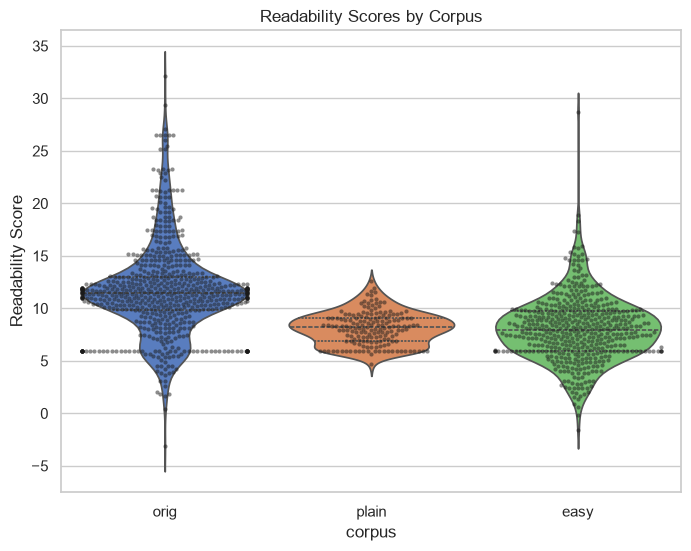

In [ ]:
# Plot the distribution using a violin plot with swarm overlay
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
# Violin plot
# sns.violinplot(x="corpus", y="score", data=df, inner="quartile", palette="muted")
# Swarm plot overlay
sns.swarmplot(x="corpus", y="score", data=df, color="k", alpha=0.5, size=3)
plt.title("Readability Scores by Corpus")
plt.ylabel("Readability Score")

# Ensure output directory exists
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)

# Save the figure
plt.savefig(output_dir / "readability_violin_swarm_plot.png", dpi=300)

plt.show()